### [K線捕手](https://www.facebook.com/kevinyang20180801)
*代老師轉發， 因为還在養病中， 今天暫時沒有訊息， 謝謝各位關心。*

[加權指數中期觀察](https://www.facebook.com/kevinyang20180801/posts/773270691473527)，樂觀一點的看法，還是可以將支撐設定在綠色的位置，目前暫時有守。但悲觀一點的看法，用藍色的畫法，今天是跌破第一天。
而長期的紅色上升趨勢線，今天已經是跌破的第一天，樂觀一點可以在觀察到下周三，悲觀一點，再過兩天沒站回，就可以用黃金分割率作修正空間的估算。
櫃買指數比較弱勢，上周就已經跌破，也符合一直提醒的，由櫃買指數帶動的跌勢。  
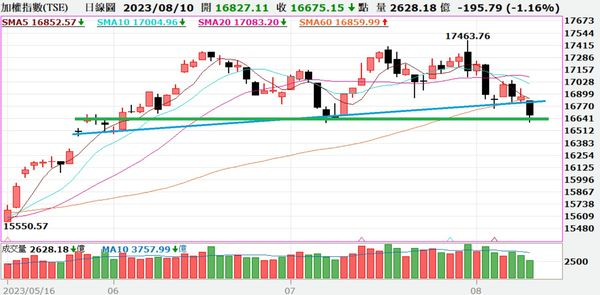  
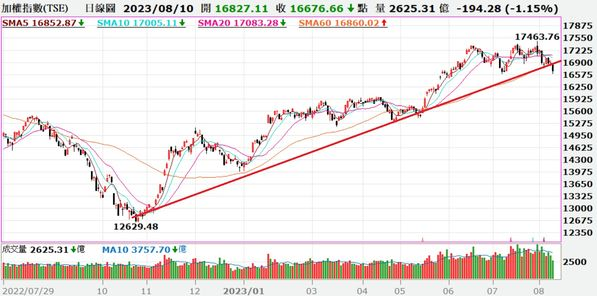  
  
[目前的策略](https://www.facebook.com/kevinyang20180801/posts/773282284805701)，倘若你先前已經預防性減碼，甚至空手，現在心情應該很輕鬆。當然，更積極的已經反手做空，反而會在逆勢獲利。而一直維持中高持股的投資人，現在壓力相對會是比較大的。  
還是要把手中個股，停損和停利點設定清楚，並且紀律執行，如果遇到離場訊號出現，但仍然猶豫不決，分批永遠是上策，部分減碼未來可攻可守，切勿毫無作為一直忍，到最後反而砍在低點。  
不過這還不是最可怕的，最高風險的操作，是指數和個股尚未止穩轉強前，無法做到減碼，還一路盲目攤平，這樣是更危險的。由多翻空會有節奏，由空翻多也是一樣，真正止穩轉強，一定會有訊號，如果未來看到會提醒大家。  
  
[當你做多賺錢的時候](https://www.facebook.com/kevinyang20180801/posts/773320668135196)，大鳴大放其實無妨，反正你賺錢，但別人沒賺到，最多就只是羨慕，乾瞪眼這樣而已。但是如果你放空賺錢，一定要記得低調一些，因為有人還套在高點，現在虧損中很煎熬。  
尤其股票本身不是零和遊戲，但做空的衍生性商品大部分都是，你大賺得同時，意味著相對應有人大賠，股市就像戰場，勝敗乃兵家常事，但做空賺到錢要記得要有同理心，還有心存慈悲。  

[台幣一度貶破31.8 遽貶原因央行說是「這2個」 挑戰32元的日子快來了？](https://wantrich.chinatimes.com/news/20230810900454-420101)  

### 本日進度  
* **暫時空手**，觀察後續盤勢發展。  
* **[參賽](https://ithelp.ithome.com.tw/users/20161619/ironman/5955)** ： 2023 iThome 鐵人賽：用Python程式進行股票技術分析  
* [Python 股票分析：Stocker 強大的股價預測分析工具 (附完整程式碼)](https://weikaiwei.com/finance/stocker/)
* 驗證：尋找頭肩型態([Automated Head and Shoulders Chart Pattern in Python](https://www.youtube.com/watch?v=6iFqjd5BOHw))

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np

In [2]:
##### 使用2022年2月25日到2023年4月7日之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_6274_230407.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

In [3]:
import myutils.HeadShoulders as hsutil

prices_close=np.array(df_k_line['Close'])
hs_patterns, ihs_patterns = hsutil.find_hs_patterns(prices_close, 10, early_find=False)
print(hs_patterns, ihs_patterns)

[] [HSPattern(inverted=True, l_shoulder=111, r_shoulder=209, l_armpit=130, r_armpit=192, head=157, l_shoulder_p=50.8, r_shoulder_p=51.4, l_armpit_p=58.0, r_armpit_p=58.4, head_p=39.4, start_i=98, break_i=218, break_p=61.3, neck_start=57.79354838709678, neck_end=58.567741935483866, neck_slope=0.006451612903225784, head_width=62, head_height=18.774193548387096, pattern_r2=0.8867081461717777)]


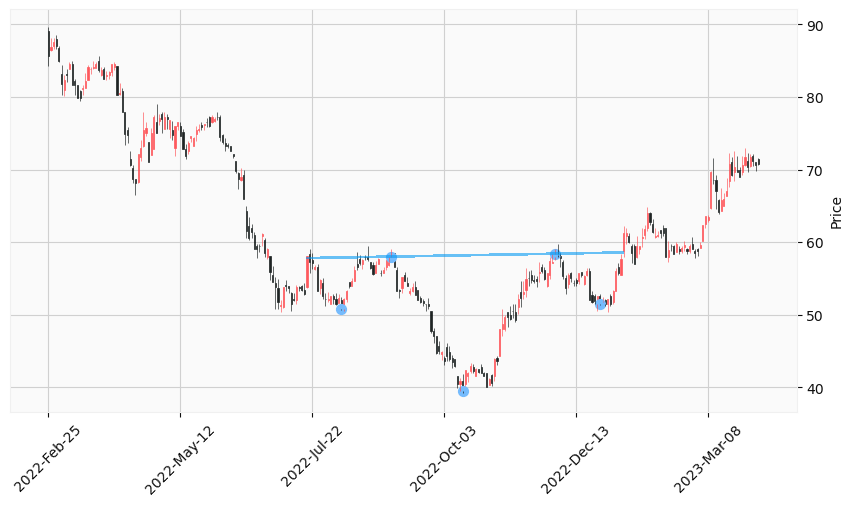

突破索引＝218，突破價格＝61.30，頸線斜率＝0.00645，頭部寬度（頭部持續期間）＝62，頭部高度＝18.77
目標價＝頭部高度18.77＋頸線結束價格58.57＝77.34


In [4]:
patterns_points_len = len(np.array(df_k_line['Close']))
patterns_points = np.array([np.nan]*patterns_points_len)

# 頭肩底的左肩
patterns_points[ihs_patterns[0].l_shoulder] = ihs_patterns[0].l_shoulder_p
# 頭肩底的右肩
patterns_points[ihs_patterns[0].r_shoulder] = ihs_patterns[0].r_shoulder_p
# 頭肩底的左腋窩
patterns_points[ihs_patterns[0].l_armpit] = ihs_patterns[0].l_armpit_p
# 頭肩底的右腋窩
patterns_points[ihs_patterns[0].r_armpit] = ihs_patterns[0].r_armpit_p
# 頭肩底的頭
patterns_points[ihs_patterns[0].head] = ihs_patterns[0].head_p

# 頸線(開始點→突破點)
neckline_start_date = df_k_line.iloc[ihs_patterns[0].start_i].name.strftime("%Y-%m-%d")
neckline_end_date = df_k_line.iloc[ihs_patterns[0].break_i].name.strftime("%Y-%m-%d")
neckline_start_price = ihs_patterns[0].neck_start
neckline_end_price = ihs_patterns[0].neck_end

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)]
                     ]

# 設定轉折點
apds = [
        mpf.make_addplot(patterns_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue')
    ]
# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds,alines=dict(alines=seq_of_seq_of_points, linewidths=1.2, colors='xkcd:azure', alpha=0.6))
mpf.plot(df_k_line,**kwargs)

# 其餘資訊
print('突破索引＝{}，突破價格＝{:.2f}，頸線斜率＝{:.5f}，頭部寬度（頭部持續期間）＝{}，頭部高度＝{:.2f}'.format(ihs_patterns[0].break_i,ihs_patterns[0].break_p,ihs_patterns[0].neck_slope,ihs_patterns[0].head_width,ihs_patterns[0].head_height))

# 試算目標價
target_price = ihs_patterns[0].head_height + ihs_patterns[0].neck_end
print('目標價＝頭部高度{:.2f}＋頸線結束價格{:.2f}＝{:.2f}'.format(ihs_patterns[0].head_height,ihs_patterns[0].neck_end,target_price))

[] [HSPattern(inverted=True, l_shoulder=111, r_shoulder=196, l_armpit=130, r_armpit=192, head=157, l_shoulder_p=50.8, r_shoulder_p=53.6, l_armpit_p=58.0, r_armpit_p=58.4, head_p=39.4, start_i=98, break_i=204, break_p=56.0, neck_start=57.79354838709678, neck_end=58.47741935483871, neck_slope=0.006451612903225784, head_width=62, head_height=18.774193548387096, pattern_r2=0.9111752066434631)]


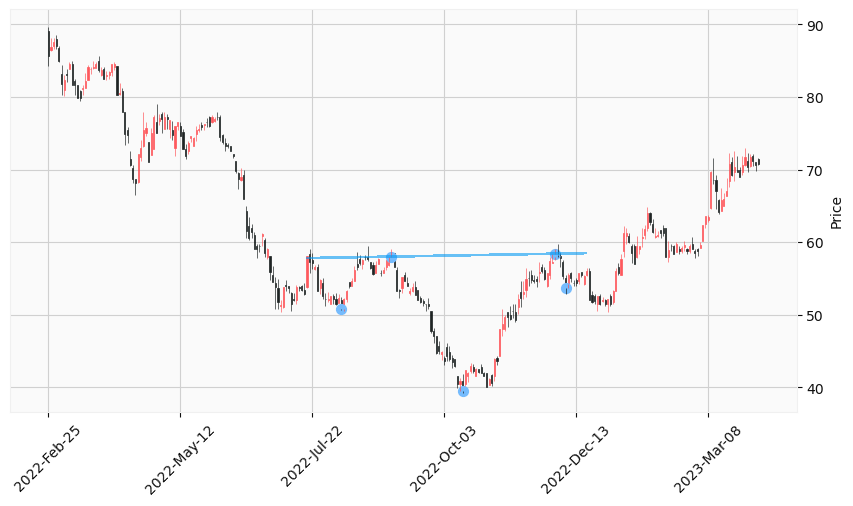

突破索引＝204，突破價格＝56.00，頸線斜率＝0.00645，頭部寬度（頭部持續期間）＝62，頭部高度＝18.77
目標價＝頭部高度18.77＋頸線結束價格58.48＝77.25


In [5]:
# 測試：early_find模式
hs_patterns, ihs_patterns = hsutil.find_hs_patterns(prices_close, 10, early_find=True)
print(hs_patterns, ihs_patterns)

patterns_points_len = len(np.array(df_k_line['Close']))
patterns_points = np.array([np.nan]*patterns_points_len)

# 頭肩底的左肩
patterns_points[ihs_patterns[0].l_shoulder] = ihs_patterns[0].l_shoulder_p
# 頭肩底的右肩
patterns_points[ihs_patterns[0].r_shoulder] = ihs_patterns[0].r_shoulder_p
# 頭肩底的左腋窩
patterns_points[ihs_patterns[0].l_armpit] = ihs_patterns[0].l_armpit_p
# 頭肩底的右腋窩
patterns_points[ihs_patterns[0].r_armpit] = ihs_patterns[0].r_armpit_p
# 頭肩底的頭
patterns_points[ihs_patterns[0].head] = ihs_patterns[0].head_p

# 頸線(開始點→突破點)
neckline_start_date = df_k_line.iloc[ihs_patterns[0].start_i].name.strftime("%Y-%m-%d")
neckline_end_date = df_k_line.iloc[ihs_patterns[0].break_i].name.strftime("%Y-%m-%d")
neckline_start_price = ihs_patterns[0].neck_start
neckline_end_price = ihs_patterns[0].neck_end

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)]
                     ]

# 設定轉折點
apds = [
        mpf.make_addplot(patterns_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue')
    ]
# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds,alines=dict(alines=seq_of_seq_of_points, linewidths=1.2, colors='xkcd:azure', alpha=0.6))
mpf.plot(df_k_line,**kwargs)

# 其餘資訊
print('突破索引＝{}，突破價格＝{:.2f}，頸線斜率＝{:.5f}，頭部寬度（頭部持續期間）＝{}，頭部高度＝{:.2f}'.format(ihs_patterns[0].break_i,ihs_patterns[0].break_p,ihs_patterns[0].neck_slope,ihs_patterns[0].head_width,ihs_patterns[0].head_height))

# 試算目標價
target_price = ihs_patterns[0].head_height + ihs_patterns[0].neck_end
print('目標價＝頭部高度{:.2f}＋頸線結束價格{:.2f}＝{:.2f}'.format(ihs_patterns[0].head_height,ihs_patterns[0].neck_end,target_price))

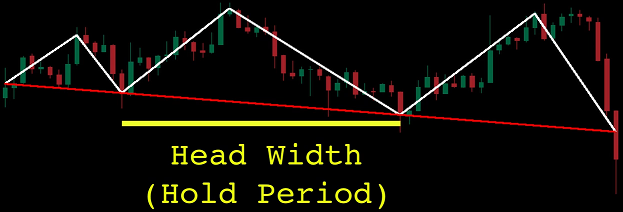  
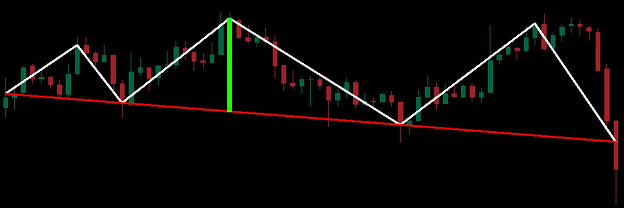

* 整合：尋找頭肩型態函式 FindingHeadShoulderPatterns()

In [6]:
import myutils

patterns = myutils.FindingHeadShoulderPatterns(df_k_line, 10)
print(patterns)

[{'type': 'Bottom', 'points': [[111, '2022-08-08', 50.8], [130, '2022-09-02', 58.0], [157, '2022-10-13', 39.4], [192, '2022-12-01', 58.4], [209, '2022-12-26', 51.4]], 'neckline': {'start_date': '2022-07-20', 'start_price': 57.79354838709678, 'end_date': '2023-01-09', 'end_price': 58.567741935483866}, 'head': {'width': 62, 'height': 18.774193548387096}}]


目標價＝頭部高度（18.77）＋頸線結束價格（58.57）＝77.34


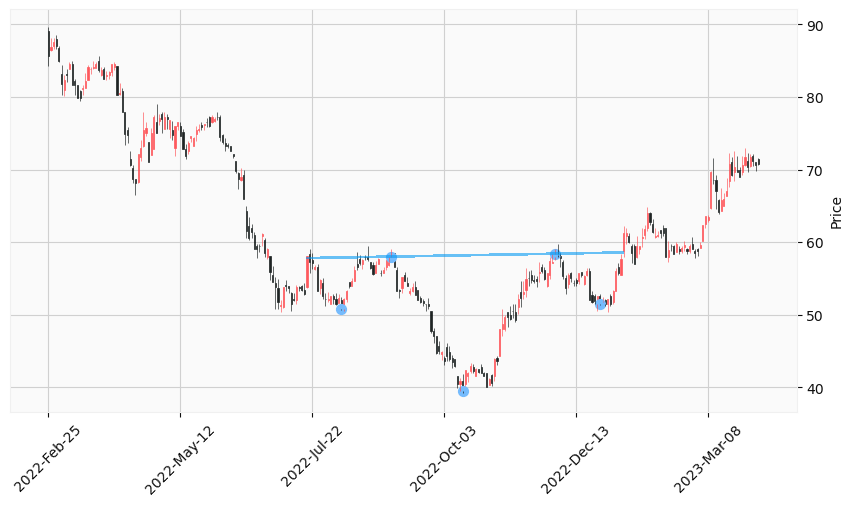

In [7]:
for pattern in patterns :
    pattern_points_len = len(np.array(df_k_line['Close']))
    pattern_points = np.array([np.nan]*pattern_points_len)
    head_shoulder_points = pattern['points']
    pattern_points[head_shoulder_points[0][0]] = head_shoulder_points[0][2]
    pattern_points[head_shoulder_points[1][0]] = head_shoulder_points[1][2]
    pattern_points[head_shoulder_points[2][0]] = head_shoulder_points[2][2]
    pattern_points[head_shoulder_points[3][0]] = head_shoulder_points[3][2]
    pattern_points[head_shoulder_points[4][0]] = head_shoulder_points[4][2]
    head_shoulder_neckline = pattern['neckline']
    head_shoulder_head     = pattern['head']
    # 試算目標價
    target_price = head_shoulder_head['height'] + head_shoulder_neckline['end_price']
    print('目標價＝頭部高度（{:.2f}）＋頸線結束價格（{:.2f}）＝{:.2f}'.format(head_shoulder_head['height'],head_shoulder_neckline['end_price'],target_price))
    # 設定K線格式
    mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
    s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
    # 設定頸線
    seq_of_seq_of_points=[
        [(head_shoulder_neckline['start_date'],head_shoulder_neckline['start_price']),(head_shoulder_neckline['end_date'],head_shoulder_neckline['end_price'])]
    ]
    # 設定轉折點
    apds = [
        mpf.make_addplot(pattern_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue')
    ]
    # 繪出K線圖
    kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds,alines=dict(alines=seq_of_seq_of_points, linewidths=1.2, colors='xkcd:azure', alpha=0.6))
    mpf.plot(df_k_line,**kwargs)

[{'type': 'Bottom', 'points': [[111, '2022-08-08', 50.8], [130, '2022-09-02', 58.0], [157, '2022-10-13', 39.4], [192, '2022-12-01', 58.4], [196, '2022-12-07', 53.6]], 'neckline': {'start_date': '2022-07-20', 'start_price': 57.79354838709678, 'end_date': '2022-12-19', 'end_price': 58.47741935483871}, 'head': {'width': 62, 'height': 18.774193548387096}}]


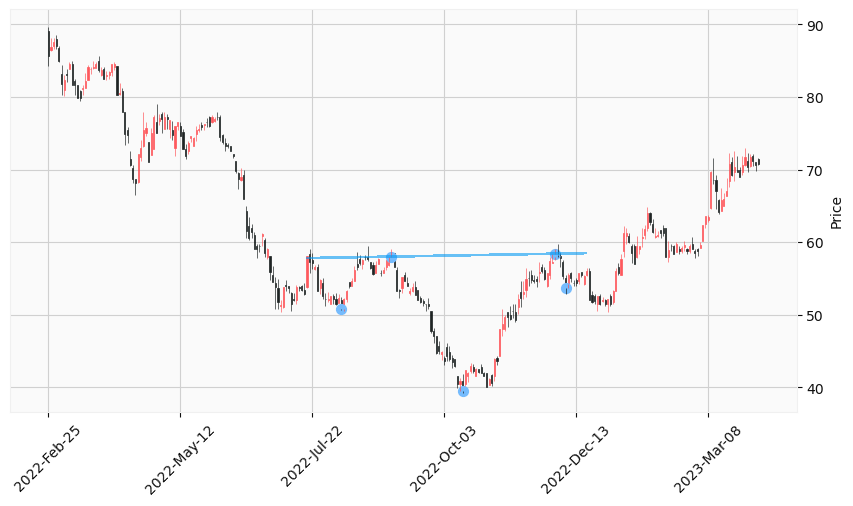

In [8]:
# 測試：early_find模式
patterns = myutils.FindingHeadShoulderPatterns(df_k_line, 10, early_find=True)
print(patterns)
for pattern in patterns :
    pattern_points_len = len(np.array(df_k_line['Close']))
    pattern_points = np.array([np.nan]*pattern_points_len)
    head_shoulder_points = pattern['points']
    pattern_points[head_shoulder_points[0][0]] = head_shoulder_points[0][2]
    pattern_points[head_shoulder_points[1][0]] = head_shoulder_points[1][2]
    pattern_points[head_shoulder_points[2][0]] = head_shoulder_points[2][2]
    pattern_points[head_shoulder_points[3][0]] = head_shoulder_points[3][2]
    pattern_points[head_shoulder_points[4][0]] = head_shoulder_points[4][2]
    head_shoulder_neckline = pattern['neckline']
    # 設定K線格式
    mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
    s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
    # 設定頸線
    seq_of_seq_of_points=[
        [(head_shoulder_neckline['start_date'],head_shoulder_neckline['start_price']),(head_shoulder_neckline['end_date'],head_shoulder_neckline['end_price'])]
    ]
    # 設定轉折點
    apds = [
        mpf.make_addplot(pattern_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue')
    ]
    # 繪出K線圖
    kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds,alines=dict(alines=seq_of_seq_of_points, linewidths=1.2, colors='xkcd:azure', alpha=0.6))
    mpf.plot(df_k_line,**kwargs)